In [69]:
%load_ext autoreload
%autoreload 2

from data.dataset import AbnormalData
# import model
import argparse
import addict

from __future__ import print_function
import os
import argparse
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
# from data import ModelNet40
from model import Pct
import numpy as np
from torch.utils.data import DataLoader
from util import cal_loss, IOStream
import sklearn.metrics as metrics
import matplotlib.pyplot as plt
import time 
#from train import trainf

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [83]:
args = addict.Dict()
args.exp_name = 'exp_1'
args.dataset = 'shapenet_anomaly'
args.batch_size = 64
args.test_batch_size = 64
args.use_sgd = True
args.lr = 0.0001
args.momentum = 0.9
args.no_cuda = False
args.seed = 1
args.eval = True

args.dropout = 0.5
args.num_points = 2048 
args.cuda = True
args.epochs = 15
args.val_every_nepoch = 5
#model_example = Pct(args)
#model_example.eval()
args.saved=True
args.name = "2kpoints_unbalancedLoss.pth"
from torch.utils.data import random_split

In [84]:
print(torch.cuda.is_available())
#import torch
#print(torch.__config__.show())

True


In [85]:
def data_split():
    device = torch.device("cuda" if args.cuda else "cpu")
    data = AbnormalData(split='test', num_points=args.num_points,device = device)
    
    # Define the sizes for training, validation, and testing sets
    train_size = int(0.7 * len(data))  # 70% for training
    val_size = int(0.15 * len(data))   # 15% for validation
    test_size = len(data) - train_size - val_size  # Remaining for testing
    
    # Use random_split to create the subsets
    train_data, val_data, test_data = random_split(data, [train_size, val_size, test_size])
    return data, train_data, val_data, test_data



data , train_data, val_data, test_data = data_split()
# Print information about the subsets
print("Number of classes:", len(data.classes))
print("Number of anomalies:", len(data.anomalies))
print("Total samples:", len(data))
print("Training samples:", len(train_data))
print("Validation samples:", len(val_data))
print("Testing samples:", len(test_data))
print("clases:",data.classes)
print("anomalies:",data.anomalies)



Number of classes: 20
Number of anomalies: 8
Total samples: 8615
Training samples: 6030
Validation samples: 1292
Testing samples: 1293
clases: ['ashtray', 'bag', 'bottle', 'bowl', 'bucket', 'cap', 'cup', 'eraser', 'headset', 'helmet', 'jar', 'microphone', 'shelf', 'tap', 'vase', 'cabinet', 'chair', 'desk', 'knife', 'screen']
anomalies: ['bulge', 'concavity', 'positive', 'broken', 'crak', 'hole', 'scratch', 'bending']


In [86]:
item = data.__getitem__(1)
print(item)

(tensor([[ 0.2728, -0.1263,  0.2548],
        [-0.4184,  0.1082, -0.2549],
        [-0.0343, -0.4391, -0.2397],
        ...,
        [-0.3146,  0.1935, -0.0159],
        [-0.1819,  0.2593,  0.3607],
        [ 0.0326,  0.0027, -0.0344]], device='cuda:0'), tensor(15, device='cuda:0'), tensor(2, device='cuda:0'))


In [87]:
def _init_():
    if not os.path.exists('checkpoints'):
        os.makedirs('checkpoints')
    if not os.path.exists('checkpoints/'+args.exp_name):
        os.makedirs('checkpoints/'+args.exp_name)
    if not os.path.exists('checkpoints/'+args.exp_name+'/'+'models'):
        os.makedirs('checkpoints/'+args.exp_name+'/'+'models')
    os.system('cp main.py checkpoints'+'/'+args.exp_name+'/'+'main.py.backup')
    os.system('cp model.py checkpoints' + '/' + args.exp_name + '/' + 'model.py.backup')
    os.system('cp util.py checkpoints' + '/' + args.exp_name + '/' + 'util.py.backup')
    os.system('cp data.py checkpoints' + '/' + args.exp_name + '/' + 'data.py.backup')

In [132]:
def trainf(args, io):

    data , train_data, val_data, test_data = data_split()
    device = torch.device("cuda" if args.cuda else "cpu")
    print(device)
    
    train_loader = DataLoader(
    train_data,
    num_workers=8,
    batch_size=args.batch_size,
    shuffle=True,
    drop_last=True,
    multiprocessing_context='spawn'
)
    val_loader = DataLoader(
    val_data,
    num_workers=8,
    batch_size=args.batch_size,
    shuffle=False,
    drop_last=True,
    multiprocessing_context='spawn'
)
    model = Pct(args,num_classes = len(data.classes),num_anomalies =len(data.anomalies) ).to(device)
    if args.saved:
        # Load the saved state dictionary
        checkpoint_path = 'checkpoints/%s/models/%s' % (args.exp_name, args.name)
        if os.path.exists(checkpoint_path):
            state_dict  = torch.load(checkpoint_path, map_location=torch.device('cuda'))  
            
            if 'module' in list(state_dict.keys())[0] and not hasattr(model, 'module'):
                # If the saved model was wrapped in DataParallel, but the current model is not
                state_dict = {k[7:]: v for k, v in state_dict.items()}  # Remove the 'module.' prefix
            model.load_state_dict(state_dict)
            # Load the state dictionary into the model
            #model.load_state_dict(checkpoint) 
        else: print("Checkpoint file does not exist. Model will be initialized with random weights.")
    
            
    # print(str(model))
    model = nn.DataParallel(model)

    if args.use_sgd:
        print("Use SGD")
        opt = optim.SGD(model.parameters(), lr=args.lr*100, momentum=args.momentum, weight_decay=5e-4)
    else:
        print("Use Adam")
        opt = optim.Adam(model.parameters(), lr=args.lr, weight_decay=1e-4)

    scheduler = CosineAnnealingLR(opt, args.epochs, eta_min=args.lr)
    
    criterion_class = cal_loss
    criterion_anomaly = torch.nn.CrossEntropyLoss()
    best_test_acc_classes = 0
    best_test_acc_anomalies = 0
    #train arrays for visualization later
    train_losses = []
    train_accuracies_class = []
    train_balanced_accuracies_class = []
    train_accuracies_anomaly = []
    train_balanced_accuracies_anomaly = []
    # val arrays for visualization later
    val_losses = []
    val_accuracies_class = []
    val_balanced_accuracies_class = []
    val_accuracies_anomaly = []
    val_balanced_accuracies_anomaly = []

    #we need to add the validation part or we can skip that? --DONE
    #we need to add the testing part 
    # we need to maybe increase the dataset maybe doubling everyoneby dublicating and by using different points 
    #visualize watever you want nah 
    # visualize the train and test with time 
    # you can work on the overall loss maybe it could be easier for you to plot it 
    # we notice that the loss of the classification was okayish 
    # dont forget the code for saving the model 
    # make a test function alone better i think 
    #so plot val and train and then test and print the acccuracy this could be 2 pages of results.
    # talk about the other part whihc is the segmetation 
    for epoch in range(args.epochs):
        print(f'epoch {epoch} start:')
        train_loss = 0.0
        count = 0.0
        model.train()
        train_pred_class = []
        train_true_class = []
        train_pred_anomaly = []
        train_true_anomaly = []
        idx = 0
        total_time = 0.0
        for data, label_class, label_anomaly in (train_loader):
            data, label_class, label_anomaly = data.to(device), label_class.to(device).squeeze(), label_anomaly.to(device)
            #print("part one")

            data = data.permute(0, 2, 1)
            batch_size = data.size()[0]
            opt.zero_grad()
            #print("part one")
            start_time = time.time()
            logits_class, logits_anomaly = model(data)
            
            #print("logits_class", logits_class[0])
            #print("label_class", label_class[0])
            
    
            loss_class = criterion_class(logits_class, label_class)
            
            loss_anomaly = criterion_anomaly(logits_anomaly, label_anomaly)
             #lossssssssssssssssssss
            loss = loss_class + 5*loss_anomaly
            ##########################

            loss.backward()
            #print("after loss backward")
            opt.step()
            #print("part one")
            scheduler.step()
            end_time = time.time()
            total_time += (end_time - start_time)
            #print("part one")
            preds_class = logits_class.max(dim=1)[1]
            preds_anomaly = logits_anomaly.max(dim=1)[1]
            #print("part one")
            count += batch_size
            train_loss += loss.item() * batch_size
        
            train_true_class.append(label_class.cpu().numpy())
            train_pred_class.append(preds_class.detach().cpu().numpy())

            train_true_anomaly.append(label_anomaly.cpu().numpy())
            train_pred_anomaly.append(preds_anomaly.detach().cpu().numpy())
            idx += 1
            
        print ('train total time is',total_time)
        train_true_class = np.concatenate(train_true_class)
        train_pred_class = np.concatenate(train_pred_class)
        train_true_anomaly = np.concatenate(train_true_anomaly)
        train_pred_anomaly = np.concatenate(train_pred_anomaly)
        outstr = 'Train %d, loss: %.6f, train acc class: %.2f%%, train avg acc class: %.2f%%, train acc anomaly: %.2f%%, train avg acc anomaly: %.2f%%' % (epoch,
                                                                        train_loss * 1.0 / count,
                                                                        metrics.accuracy_score(train_true_class, train_pred_class) * 100,
                                                                        metrics.balanced_accuracy_score(train_true_class, train_pred_class) * 100,
                                                                        metrics.accuracy_score(train_true_anomaly, train_pred_anomaly) * 100,
                                                                        metrics.balanced_accuracy_score(train_true_anomaly, train_pred_anomaly) * 100
                                                                        )
        
        # Append metrics to lists for plotting
        train_losses.append(train_loss * 1.0 / count)
        train_accuracies_class.append(metrics.accuracy_score(train_true_class, train_pred_class))
        train_balanced_accuracies_class.append(metrics.balanced_accuracy_score(train_true_class, train_pred_class))
        train_accuracies_anomaly.append(metrics.accuracy_score(train_true_anomaly, train_pred_anomaly))
        train_balanced_accuracies_anomaly.append(metrics.balanced_accuracy_score(train_true_anomaly, train_pred_anomaly))

        io.cprint(outstr)
        
        
        # Validation Loop
        if (epoch % args.val_every_nepoch ==0):
            
            model.eval()  # Set the model to evaluation mode
            val_loss = 0.0
            val_count = 0.0
            val_true_class = []
            val_pred_class = []
            val_true_anomaly = []
            val_pred_anomaly = []
            
            with torch.no_grad():  # Disable gradient computation during validation
                for val_data, val_label_class, val_label_anomaly in val_loader:
                    val_data, val_label_class, val_label_anomaly = val_data.to(device), val_label_class.to(device).squeeze(), val_label_anomaly.to(device)
                    val_data = val_data.permute(0, 2, 1)
                    
                    val_logits_class, val_logits_anomaly = model(val_data)
                    val_loss_class = criterion_class(val_logits_class, val_label_class)
                    val_loss_anomaly = criterion_anomaly(val_logits_anomaly, val_label_anomaly)
                    
                    #the losss summ
                    val_loss = val_loss_class + 5*val_loss_anomaly
                    # #############
                    
                    val_preds_class = val_logits_class.max(dim=1)[1]
                    val_preds_anomaly = val_logits_anomaly.max(dim=1)[1]
        
                    val_count += val_data.size(0)
                    val_loss += val_loss.item() * val_data.size(0)
        
                    val_true_class.append(val_label_class.cpu().numpy())
                    val_pred_class.append(val_preds_class.detach().cpu().numpy())
        
                    val_true_anomaly.append(val_label_anomaly.cpu().numpy())
                    val_pred_anomaly.append(val_preds_anomaly.detach().cpu().numpy())
        
            # Calculate and print validation metrics
            val_loss /= val_count
            val_true_class = np.concatenate(val_true_class)
            val_pred_class = np.concatenate(val_pred_class)
            val_true_anomaly = np.concatenate(val_true_anomaly)
            val_pred_anomaly = np.concatenate(val_pred_anomaly)
            
            val_outstr = 'Validation %d, loss: %.6f, val acc class: %.2f%%, val avg acc class: %.2f%%, val acc anomaly: %.2f%%, val avg acc anomaly: %.2f%%' % (epoch,
                                                                            val_loss,
                                                                            metrics.accuracy_score(val_true_class, val_pred_class) * 100,
                                                                            metrics.balanced_accuracy_score(val_true_class, val_pred_class) * 100,
                                                                            metrics.accuracy_score(val_true_anomaly, val_pred_anomaly) * 100,
                                                                            metrics.balanced_accuracy_score(val_true_anomaly, val_pred_anomaly) * 100
                                                                            )

            # Append metrics to lists for plotting
            val_losses.append(val_loss)
            val_accuracies_class.append(metrics.accuracy_score(val_true_class, val_pred_class))
            val_balanced_accuracies_class.append(metrics.balanced_accuracy_score(val_true_class, val_pred_class))
            val_accuracies_anomaly.append(metrics.accuracy_score(val_true_anomaly, val_pred_anomaly))
            val_balanced_accuracies_anomaly.append(metrics.balanced_accuracy_score(val_true_anomaly, val_pred_anomaly))
        
            io.cprint(val_outstr)
            # Ensure the directory exists before saving the model
            save_dir = 'checkpoints/%s/models/' % args.exp_name
            os.makedirs(save_dir, exist_ok=True)
            
            # Save the model
            torch.save(model.state_dict(), os.path.join(save_dir, '1kpoints_unbalancedLoss.pth'))

    train_accuracies = [train_losses, train_accuracies_class, train_balanced_accuracies_class, train_accuracies_anomaly, train_balanced_accuracies_anomaly]
    val_accuracies = [val_losses, val_accuracies_class, val_balanced_accuracies_class, val_accuracies_anomaly, val_balanced_accuracies_anomaly]
    #torch.save(model.state_dict(), 'workspace/pct-point-cloud-transformer-modified-main/checkpoints/%s/models/model.t7' % args.exp_name)
    
    return model,train_accuracies,val_accuracies




In [89]:

#creating the IOSream
if not os.path.exists('outputs/' + args.exp_name):
    os.mkdir('outputs/' + args.exp_name)
io = IOStream('outputs/' + args.exp_name + '/run.log')

# starting the traininig
model , train_acc , val_acc = trainf(args, io)        
#unwinding the arrays
train_losses, train_accuracies_class, train_balanced_accuracies_class, train_accuracies_anomaly, train_balanced_accuracies_anomaly = train_acc
val_losses, val_accuracies_class, val_balanced_accuracies_class, val_accuracies_anomaly, val_balanced_accuracies_anomaly = val_acc

# Ensure the directory exists before saving the model
save_dir = 'checkpoints/%s/models/' % args.exp_name
os.makedirs(save_dir, exist_ok=True)

# Save the model
torch.save(model.state_dict(), os.path.join(save_dir, '2kpoints_unbalancedLoss.pth'))


cuda
Use SGD
epoch 0 start:


[W CudaIPCTypes.cpp:16] Producer process has been terminated before all shared CUDA tensors released. See Note [Sharing CUDA tensors]


train total time is 27.9215304851532
Train 0, loss: 10.384551, train acc class: 35.44%, train avg acc class: 25.22%, train acc anomaly: 39.61%, train avg acc anomaly: 12.16%


[W CudaIPCTypes.cpp:16] Producer process has been terminated before all shared CUDA tensors released. See Note [Sharing CUDA tensors]


Validation 0, loss: 0.544277, val acc class: 33.67%, val avg acc class: 24.40%, val acc anomaly: 37.27%, val avg acc anomaly: 12.17%
epoch 1 start:


...

train total time is 27.286656379699707
Train 12, loss: 9.356690, train acc class: 57.86%, train avg acc class: 51.22%, train acc anomaly: 44.13%, train avg acc anomaly: 12.74%
epoch 13 start:


ERROR: Unexpected segmentation fault encountered in worker.
 [W CudaIPCTypes.cpp:16] Producer process has been terminated before all shared CUDA tensors released. See Note [Sharing CUDA tensors]


train total time is 27.86306667327881
Train 13, loss: 9.416498, train acc class: 53.74%, train avg acc class: 47.08%, train acc anomaly: 44.38%, train avg acc anomaly: 12.56%
epoch 14 start:


[W CudaIPCTypes.cpp:16] Producer process has been terminated before all shared CUDA tensors released. See Note [Sharing CUDA tensors]


train total time is 27.432763814926147
Train 14, loss: 9.586690, train acc class: 47.34%, train avg acc class: 40.82%, train acc anomaly: 43.75%, train avg acc anomaly: 12.41%


In [13]:
#torch.save(model.state_dict(), os.path.join(save_dir, args.name))

In [94]:
def test(model):

    data , train_data, val_data, test_data = data_split()
    
    test_loader = DataLoader(
    test_data,
    num_workers=8,
    batch_size=args.test_batch_size,  # Adjust this as needed
    shuffle=False,
    drop_last=False,
    multiprocessing_context='spawn'
    
)
    if args.use_sgd:
        print("Use SGD")
        opt = optim.SGD(model.parameters(), lr=args.lr*100, momentum=args.momentum, weight_decay=5e-4)
    else:
        print("Use Adam")
        opt = optim.Adam(model.parameters(), lr=args.lr, weight_decay=1e-4)
    scheduler = CosineAnnealingLR(opt, args.epochs, eta_min=args.lr)
    
    criterion_class = cal_loss
    criterion_anomaly = torch.nn.CrossEntropyLoss()
    model.eval()  # Set the model to evaluation mode
    test_loss = 0.0
    count = 0.0
    test_pred_class = []
    test_true_class = []
    test_pred_anomaly = []
    test_true_anomaly = []

    # test arrays for visualization later
    test_losses = []
    test_accuracies_class = []
    test_balanced_accuracies_class = []
    test_accuracies_anomaly = []
    test_balanced_accuracies_anomaly = []
    with torch.no_grad():
        for data, label_class, label_anomaly in test_loader:
            data, label_class, label_anomaly = data.to(device), label_class.to(device).squeeze(), label_anomaly.to(device)
    
            data = data.permute(0, 2, 1)
            batch_size = data.size()[0]
    
            logits_class, logits_anomaly = model(data)
    
            loss_class = criterion_class(logits_class, label_class)
            loss_anomaly = criterion_anomaly(logits_anomaly, label_anomaly)
            loss = loss_class + 5*loss_anomaly
    
            preds_class = logits_class.max(dim=1)[1]
            preds_anomaly = logits_anomaly.max(dim=1)[1]
    
            count += batch_size
            test_loss += loss.item() * batch_size
    
            test_true_class.append(label_class.cpu().numpy())
            test_pred_class.append(preds_class.detach().cpu().numpy())
    
            test_true_anomaly.append(label_anomaly.cpu().numpy())
            test_pred_anomaly.append(preds_anomaly.detach().cpu().numpy())
    
    # Calculate metrics for the test set
    test_true_class = np.concatenate(test_true_class)
    test_pred_class = np.concatenate(test_pred_class)
    test_true_anomaly = np.concatenate(test_true_anomaly)
    test_pred_anomaly = np.concatenate(test_pred_anomaly)
    
    test_outstr = 'Test, loss: %.6f, test acc class: %.2f%%, test avg acc class: %.2f%%, test acc anomaly: %.2f%%, test avg acc anomaly: %.2f%%' % (
        test_loss * 1.0 / count,
        metrics.accuracy_score(test_true_class, test_pred_class) * 100,
        metrics.balanced_accuracy_score(test_true_class, test_pred_class) * 100,
        metrics.accuracy_score(test_true_anomaly, test_pred_anomaly) * 100,
        metrics.balanced_accuracy_score(test_true_anomaly, test_pred_anomaly) * 100
    )
            # Append metrics to lists for plotting
    test_losses.append(test_loss)
    test_accuracies_class.append(metrics.accuracy_score(test_true_class, test_pred_class))
    test_balanced_accuracies_class.append(metrics.balanced_accuracy_score(test_true_class, test_pred_class))
    test_accuracies_anomaly.append(metrics.accuracy_score(test_true_anomaly, test_pred_anomaly))
    test_balanced_accuracies_anomaly.append(metrics.balanced_accuracy_score(test_true_anomaly, test_pred_anomaly))
    
    test_accuracies = [test_losses, test_accuracies_class, test_balanced_accuracies_class, test_accuracies_anomaly, test_balanced_accuracies_anomaly]
    print(test_outstr)
    return test_accuracies

In [136]:
test_accuracies = test(model)

Use SGD


[W CudaIPCTypes.cpp:16] Producer process has been terminated before all shared CUDA tensors released. See Note [Sharing CUDA tensors]


Test, loss: 7.835583, test acc class: 96.75%, test avg acc class: 96.80%, test acc anomaly: 46.25%, test avg acc anomaly: 14.06%


ValueError: x and y must have same first dimension, but have shapes (20,) and (15,)

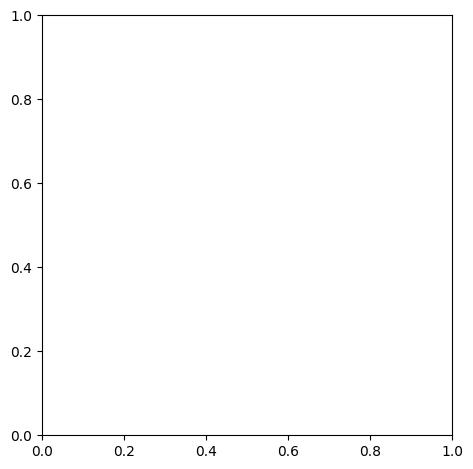

In [137]:
# Visualization of the results of training and validation:
def vissualize(train_acc,val_acc,args):
    x = args.val_every_nepoch
    train_losses, train_accuracies_class, train_balanced_accuracies_class, train_accuracies_anomaly, train_balanced_accuracies_anomaly = train_acc
    val_losses, val_accuracies_class, val_balanced_accuracies_class, val_accuracies_anomaly, val_balanced_accuracies_anomaly = val_acc
    val_losses_np = [loss.cpu().numpy() if isinstance(loss, torch.Tensor) else np.array(loss) for loss in val_losses]
    
    # Plotting
    plt.figure(figsize=(18, 12))
    epochs = np.arange(0, args.epochs, 1)
    # Training Loss
    plt.subplot(2, 3, 1)
    plt.plot(epochs, train_losses, label='Train Loss')
    #plt.plot(epochs[::5], val_losses, marker='o', linestyle='-', color='r', label='Validation Loss (every 5 epochs)')
    #plt.plot(range(args.epochs), val_losses, label='Validation Loss')
    plt.title('Training Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    
    # Training Accuracy for Classification
    plt.subplot(2, 3, 2)
    plt.plot(range(args.epochs), train_accuracies_class, label='Train Accuracy')
    plt.plot(range(args.epochs), train_balanced_accuracies_class, label='Train Balanced Accuracy')
    plt.title('Training Accuracy for Classification')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    
    # Training Accuracy for Anomaly Detection
    plt.subplot(2, 3, 3)
    plt.plot(range(args.epochs), train_accuracies_anomaly, label='Train Accuracy')
    plt.plot(range(args.epochs), train_balanced_accuracies_anomaly, label='Train Balanced Accuracy')
    plt.title('Training Accuracy for Anomaly Detection')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    
    #Validation loss
    plt.subplot(2, 3, 4)
    #plt.plot(epochs, train_losses, label='Train Loss')
    plt.plot(epochs[::x], val_losses_np, marker='o', linestyle='-', color='r', label='Validation Loss (every 5 epochs)')
    #plt.plot(range(args.epochs), val_losses, label='Validation Loss')
    plt.title(' Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    
    
    
    # Validation Accuracy for Classification
    plt.subplot(2, 3, 5)
    plt.plot(epochs[::x], val_accuracies_class, label='Validation Accuracy')
    plt.plot(epochs[::x], val_balanced_accuracies_class, label='Validation Balanced Accuracy')
    plt.title('Validation Accuracy for Classification')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    
    # Validation Accuracy for Anomaly Detection
    plt.subplot(2, 3, 6)
    plt.plot(epochs[::x], val_accuracies_anomaly, label='Validation Accuracy')
    plt.plot(epochs[::x], val_balanced_accuracies_anomaly, label='Validation Balanced Accuracy')
    plt.title('Validation Accuracy for Anomaly Detection')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    
    # Show the plots
    plt.tight_layout()
    plt.show()
vissualize(train_acc,val_acc,args)

In [133]:
args = addict.Dict()
args.exp_name = 'exp_2'
args.dataset = 'shapenet_anomaly'
args.batch_size = 64
args.test_batch_size = 64
args.use_sgd = True
args.lr = 0.0001
args.momentum = 0.9
args.no_cuda = False
args.seed = 1
args.eval = True
# args.model_path = 'models/model.t7'
args.dropout = 0.5
args.num_points = 1024 # 
args.cuda = True
args.epochs = 20
args.val_every_nepoch = 3
#model_example = Pct(args)
#model_example.eval()
args.saved=True
args.name = "1kpoints_unbalancedLoss.pth"
from torch.utils.data import random_split

In [134]:

#creating the IOSream
if not os.path.exists('outputs/' + args.exp_name):
    os.mkdir('outputs/' + args.exp_name)
io = IOStream('outputs/' + args.exp_name + '/run.log')

# starting the traininig
model , train_acc_1 , val_acc_1 = trainf(args, io)        
#unwinding the arrays
train_losses_1, train_accuracies_class_1, train_balanced_accuracies_class_1, train_accuracies_anomaly_1, train_balanced_accuracies_anomaly_1 = train_acc_1
val_losses_1, val_accuracies_class_1, val_balanced_accuracies_class_1, val_accuracies_anomaly_1, val_balanced_accuracies_anomaly_1 = val_acc_1

# Ensure the directory exists before saving the model
save_dir = 'checkpoints/%s/models/' % args.exp_name
os.makedirs(save_dir, exist_ok=True)

# Save the model
torch.save(model.state_dict(), os.path.join(save_dir, '1kpoints_unbalancedLoss.pth'))


cuda
Checkpoint file does not exist. Model will be initialized with random weights.
Use SGD
epoch 0 start:


[W CudaIPCTypes.cpp:16] Producer process has been terminated before all shared CUDA tensors released. See Note [Sharing CUDA tensors]


train total time is 23.845569372177124
Train 0, loss: 11.177252, train acc class: 27.33%, train avg acc class: 14.53%, train acc anomaly: 38.05%, train avg acc anomaly: 12.43%


[W CudaIPCTypes.cpp:16] Producer process has been terminated before all shared CUDA tensors released. See Note [Sharing CUDA tensors]


Validation 0, loss: 0.491360, val acc class: 33.59%, val avg acc class: 23.02%, val acc anomaly: 39.53%, val avg acc anomaly: 12.37%
epoch 1 start:


...

train total time is 23.586734771728516
Train 18, loss: 8.187429, train acc class: 92.74%, train avg acc class: 91.28%, train acc anomaly: 43.28%, train avg acc anomaly: 15.86%


[W CudaIPCTypes.cpp:16] Producer process has been terminated before all shared CUDA tensors released. See Note [Sharing CUDA tensors]


Validation 18, loss: 0.353128, val acc class: 97.27%, val avg acc class: 98.51%, val acc anomaly: 43.59%, val avg acc anomaly: 12.48%
epoch 19 start:


[W CudaIPCTypes.cpp:16] Producer process has been terminated before all shared CUDA tensors released. See Note [Sharing CUDA tensors]


train total time is 23.61304473876953
Train 19, loss: 8.021628, train acc class: 93.37%, train avg acc class: 92.27%, train acc anomaly: 43.75%, train avg acc anomaly: 16.05%


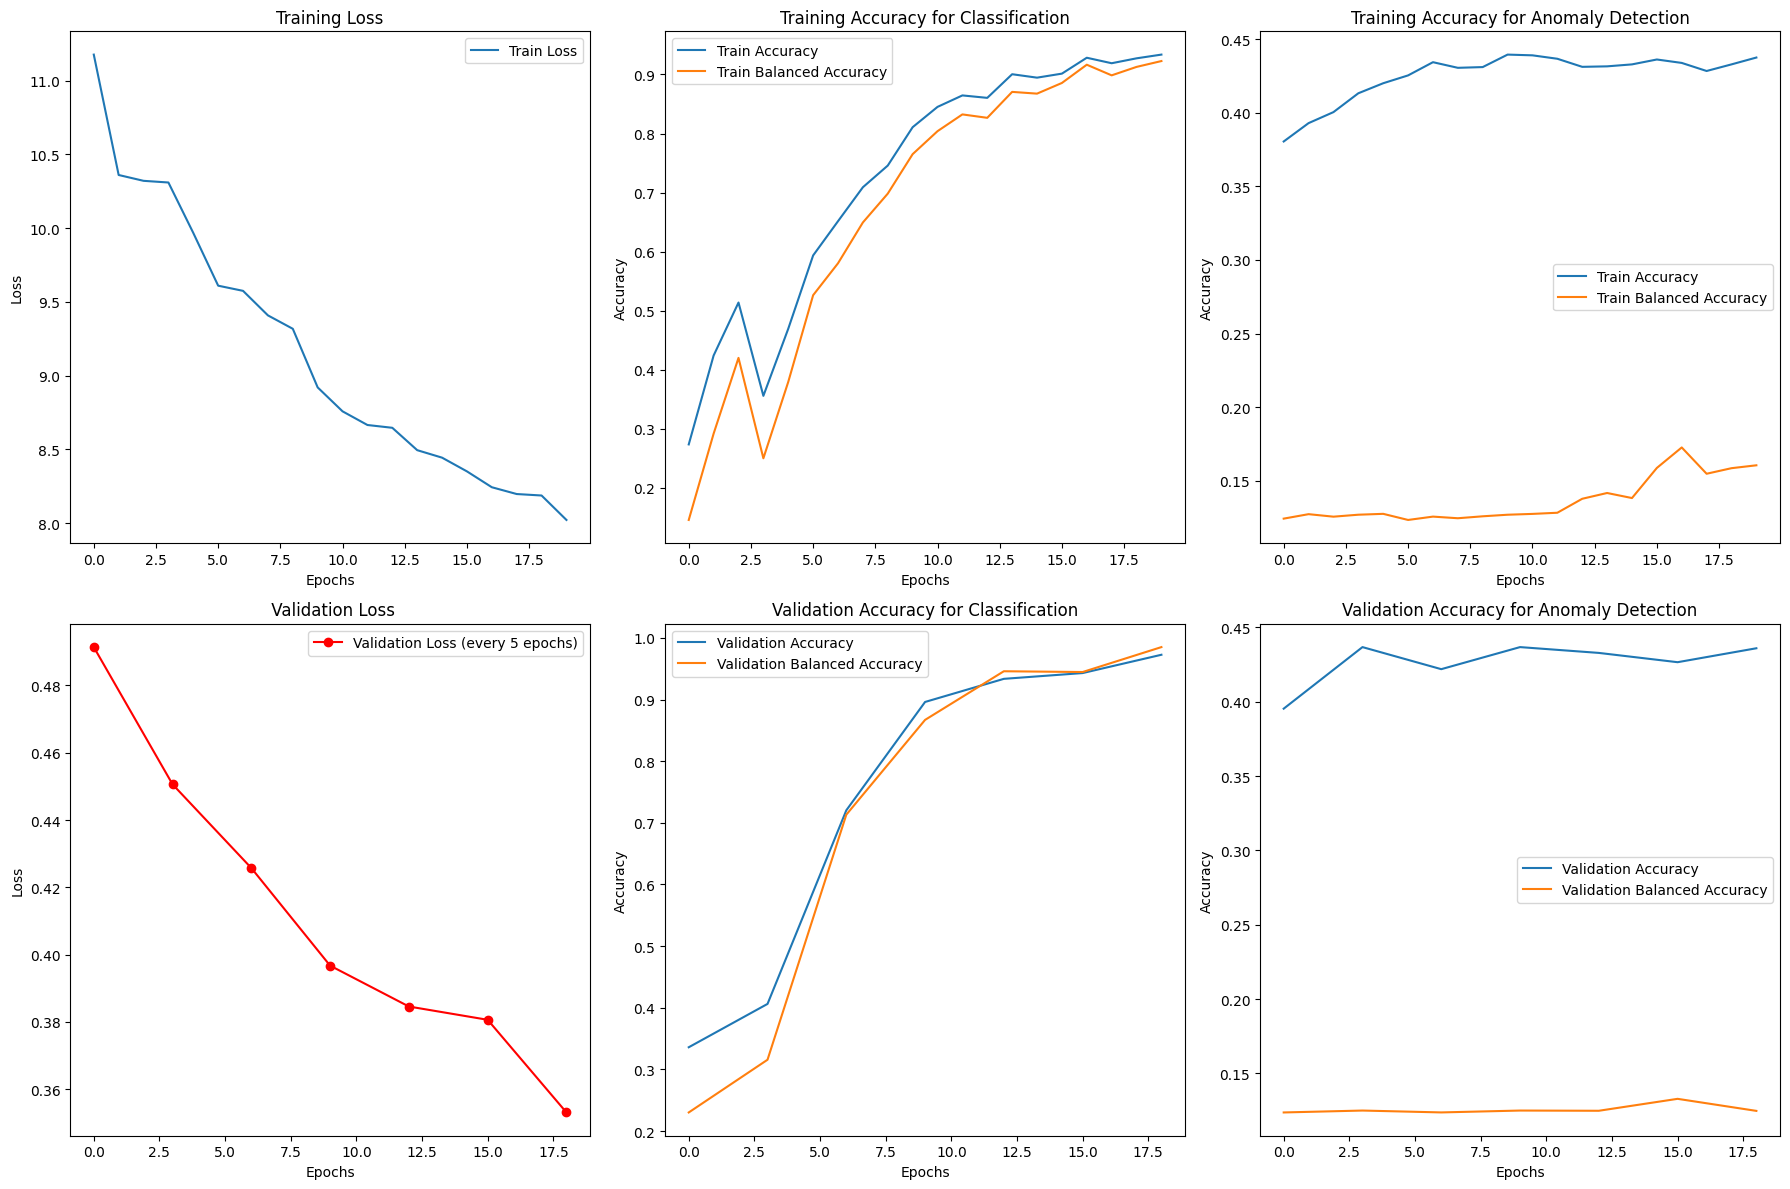

In [138]:
vissualize(train_acc_1, val_acc_1,args)